In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version: 2.6.0
GPU available: True
GPU name: Tesla T4


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Paths
TRAIN_DIR = '/home/sagemaker-user/dataset_classification/Training'
TEST_DIR  = '/home/sagemaker-user/dataset_classification/Testing'

# Check classes and image counts
for split_name, split_path in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    classes = sorted(os.listdir(split_path))
    print(f"\n{split_name} classes: {classes}")
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"  {cls}: {count} images")


Train classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 826 images
  meningioma_tumor: 822 images
  no_tumor: 395 images
  pituitary_tumor: 827 images

Test classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 100 images
  meningioma_tumor: 115 images
  no_tumor: 105 images
  pituitary_tumor: 74 images


In [4]:
%pip install opencv-python
import cv2
from torchvision.transforms import functional as F

class CLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img = np.array(img)
        if len(img.shape) == 3:
            # Apply CLAHE to L channel in LAB space
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            lab[:, :, 0] = self.clahe.apply(lab[:, :, 0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

class GaussianNoise(object):
    def __init__(self, std=0.02):
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std

print("Custom transforms defined ✓")

Note: you may need to restart the kernel to use updated packages.
Custom transforms defined ✓


In [5]:
# Image size
IMG_SIZE = 224

train_transforms = transforms.Compose([
    CLAHE(clip_limit=2.0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    GaussianNoise(std=0.02)
])

test_transforms = transforms.Compose([
    CLAHE(clip_limit=2.0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms defined ✓")

Transforms defined ✓


In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, ConcatDataset

# Load both folders separately to get targets
train_data = datasets.ImageFolder(TRAIN_DIR)
test_data  = datasets.ImageFolder(TEST_DIR)

# Combine targets and indices
targets = train_data.targets + test_data.targets
indices = list(range(len(targets)))
class_names = train_data.classes
print(f"Classes: {class_names}")
print(f"Total samples (combined): {len(targets)}")

# 70/15/15 stratified split
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=42
)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_targets, random_state=42
)

# Build combined dataset with transforms
train_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=train_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=train_transforms)
]), train_idx)

val_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=test_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
]), val_idx)

test_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=test_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
]), test_idx)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Verify stratification
for name, idx_list in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    split_targets = [targets[i] for i in idx_list]
    counts = Counter(split_targets)
    print(f"{name}: { {class_names[k]: v for k, v in sorted(counts.items())} }")

# Save split indices for teammates
import json
split_indices = {'train': train_idx, 'val': val_idx, 'test': test_idx}
with open('/home/sagemaker-user/NeuroVision/split_indices.json', 'w') as f:
    json.dump(split_indices, f)
print("\nSplit indices saved ✓")

# Weighted sampler
train_targets = [targets[i] for i in train_idx]
class_counts  = Counter(train_targets)
weights       = [1.0 / class_counts[t] for t in train_targets]
sampler       = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders
BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready ✓")

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Total samples (combined): 3264

Train: 2284 | Val: 490 | Test: 490
Train: {'glioma_tumor': 648, 'meningioma_tumor': 656, 'no_tumor': 350, 'pituitary_tumor': 630}
Val: {'glioma_tumor': 139, 'meningioma_tumor': 140, 'no_tumor': 75, 'pituitary_tumor': 136}
Test: {'glioma_tumor': 139, 'meningioma_tumor': 141, 'no_tumor': 75, 'pituitary_tumor': 135}

Split indices saved ✓
DataLoaders ready ✓


In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialise and move to GPU
model = CustomCNN(num_classes=4).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [8]:
# Class weights from combined dataset
class_counts_all = Counter(targets)
total = len(targets)
class_weights = torch.tensor(
    [total / class_counts_all[i] for i in range(4)],
    dtype=torch.float
).to(device)

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Loss, optimizer, scheduler ready ✓")
print(f"Class weights: { {class_names[i]: round(class_weights[i].item(), 3) for i in range(4)} }")

Loss, optimizer, scheduler ready ✓
Class weights: {'glioma_tumor': 3.525, 'meningioma_tumor': 3.483, 'no_tumor': 6.528, 'pituitary_tumor': 3.623}


In [9]:
NUM_EPOCHS       = 50
EARLY_STOP       = 10
best_val_loss    = float('inf')
no_improve       = 0
best_model_path  = '/home/sagemaker-user/NeuroVision/custom_cnn_best.pth'

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = 100. * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    # Early stopping + best model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), best_model_path)
        saved = "← saved"
    else:
        no_improve += 1
        saved = ""

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% | "
          f"No improve: {no_improve}/{EARLY_STOP} {saved}")

    if no_improve >= EARLY_STOP:
        print(f"\nEarly stopping triggered at epoch {epoch+1} ✓")
        break

print("\nTraining complete ✓")
print(f"Best val loss: {best_val_loss:.4f}")

Epoch [01/50] Train Loss: 5.1108 Acc: 43.6% | Val Loss: 0.9282 Acc: 59.8% | No improve: 0/10 ← saved
Epoch [02/50] Train Loss: 0.9702 Acc: 57.0% | Val Loss: 0.7691 Acc: 66.7% | No improve: 0/10 ← saved
Epoch [03/50] Train Loss: 0.8813 Acc: 61.5% | Val Loss: 0.7437 Acc: 66.7% | No improve: 0/10 ← saved
Epoch [04/50] Train Loss: 0.8155 Acc: 65.6% | Val Loss: 0.7048 Acc: 66.9% | No improve: 0/10 ← saved
Epoch [05/50] Train Loss: 0.7684 Acc: 66.0% | Val Loss: 0.6583 Acc: 74.9% | No improve: 0/10 ← saved
Epoch [06/50] Train Loss: 0.7530 Acc: 65.9% | Val Loss: 0.5647 Acc: 76.7% | No improve: 0/10 ← saved
Epoch [07/50] Train Loss: 0.7052 Acc: 68.9% | Val Loss: 0.5562 Acc: 75.9% | No improve: 0/10 ← saved
Epoch [08/50] Train Loss: 0.6630 Acc: 70.8% | Val Loss: 0.5249 Acc: 79.0% | No improve: 0/10 ← saved
Epoch [09/50] Train Loss: 0.6500 Acc: 71.2% | Val Loss: 0.5566 Acc: 77.1% | No improve: 1/10 
Epoch [10/50] Train Loss: 0.6310 Acc: 72.9% | Val Loss: 0.4896 Acc: 76.7% | No improve: 0/10 ← sav

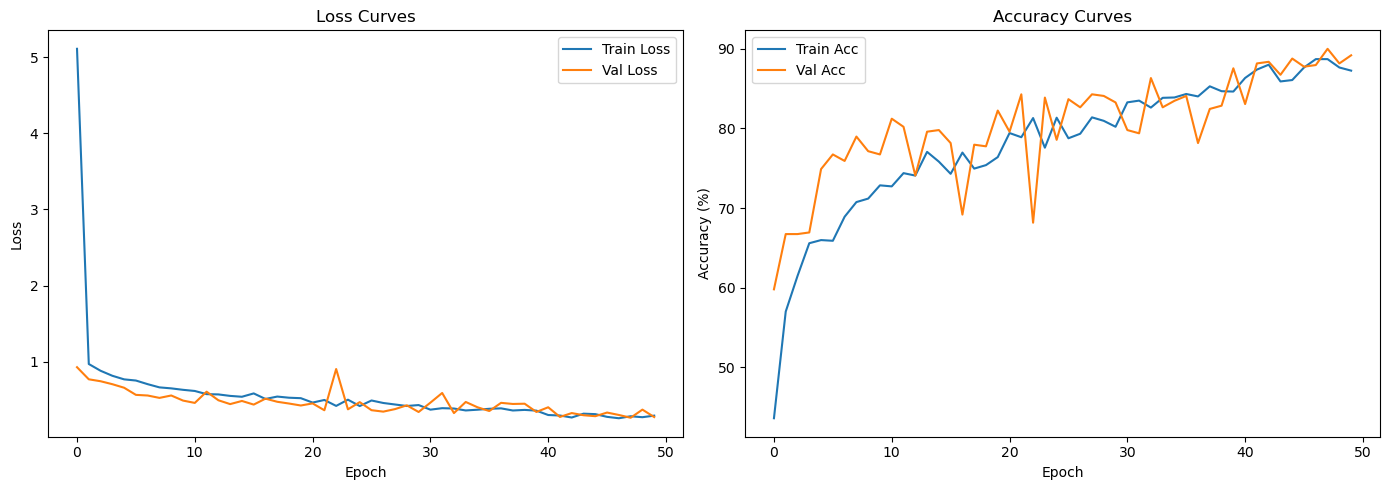

Training curves saved ✓


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/custom_cnn_training_curves.png', dpi=150)
plt.show()
print("Training curves saved ✓")

In [11]:
# Load best saved model
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Weighted F1 — primary metric
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Weighted F1 Score: {weighted_f1:.4f}")

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.74      0.84       139
meningioma_tumor       0.77      0.84      0.80       141
        no_tumor       0.87      0.96      0.91        75
 pituitary_tumor       0.89      0.96      0.93       135

        accuracy                           0.87       490
       macro avg       0.87      0.88      0.87       490
    weighted avg       0.87      0.87      0.86       490

Weighted F1 Score: 0.8643


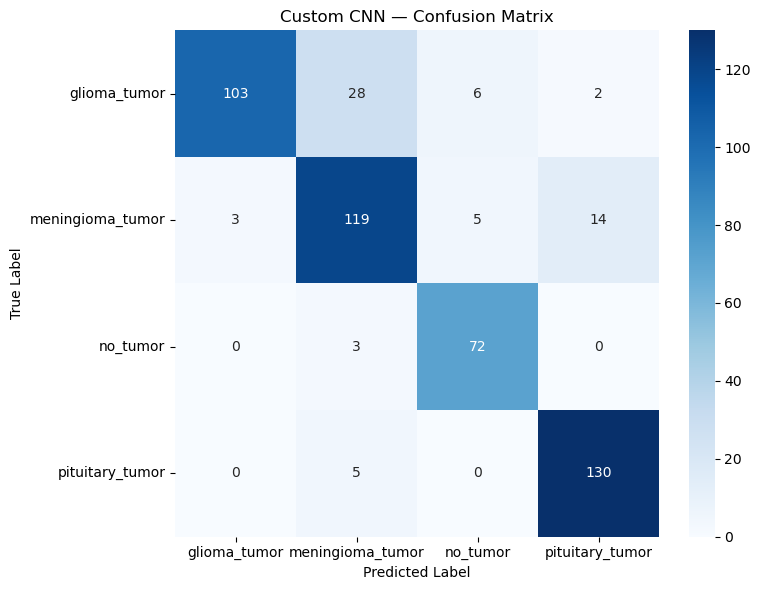

In [12]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Custom CNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/custom_cnn_confusion_matrix.png', dpi=150)
plt.show()

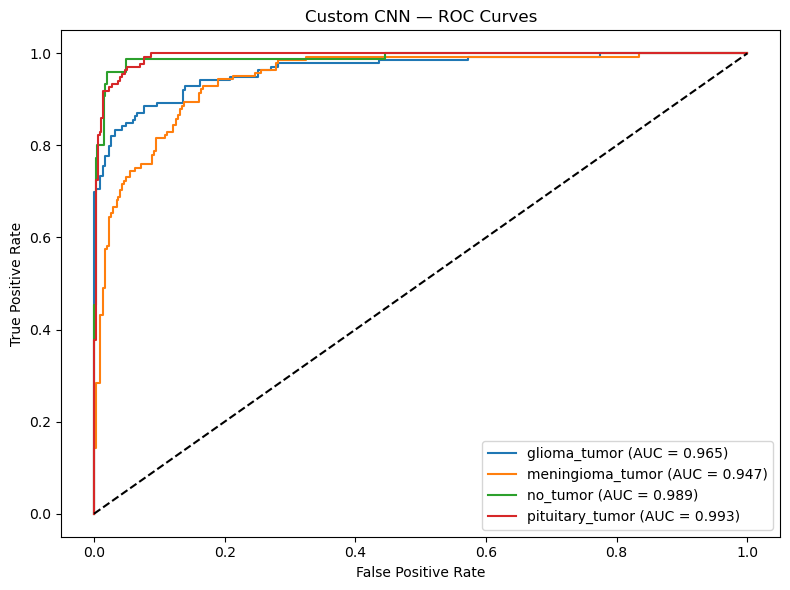

Weighted ROC-AUC: 0.9711


In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Binarize labels for multiclass ROC
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('Custom CNN — ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/custom_cnn_roc_curves.png', dpi=150)
plt.show()

overall_auc = roc_auc_score(all_labels_bin, all_probs, average='weighted')
print(f"Weighted ROC-AUC: {overall_auc:.4f}")